In [1]:
# imports

import os, re, json, pickle, torch
import numpy as np
import pandas as pd
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import f1_score, accuracy_score

# model 2 - bert
import torch
from torch.utils.data import Dataset, DataLoader # Added Dataset
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from sklearn.metrics import f1_score # Added f1_score
from tqdm import tqdm

# model 3 - hybrid 
import optuna

# model 4 - lstm 
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
from sklearn.metrics import f1_score

# Suppress minor warnings for cleaner output
warnings.filterwarnings("ignore", category=FutureWarning)

### data crawl
* preprocessing included in moviedataorchestrator 
    * clean currency
    * normalize rating 

In [7]:
class MovieWorkflowManager:
    def __init__(self):
        self.base_path = os.getcwd() 
        self.folders = {
            "audience-reviews":      {"type": "audience", "platform": "rt"},
            "critic-reviews-rt":        {"type": "critic",   "platform": "rt"},
            "audience-reviews-imdb": {"type": "audience", "platform": "imdb"},
            # "critic-reviews-metacritic": {"type": "critic",   "platform": "metacritic"}
        }
        self.stats = {"scraped_files": 0, "dropped_no_finance": 0, "final_movies": 0}

    def clean_val(self, v):
        if pd.isna(v) or v == "N/A": return np.nan
        s = re.sub(r'[^\d.]', '', str(v))
        return float(s) if s else np.nan

    def slugify(self, filename):
        name = os.path.splitext(filename)[0].lower()
        for term in ["reviews", "imdb", "rt", "roger", "ebert", "metadata", "audience", "critic"]:
            name = name.replace(term, "")
        return name.strip("_")

    def load_master_metadata(self):
        meta_list = []
        for folder in self.folders.keys():
            path = os.path.join(self.base_path, folder)
            if not os.path.exists(path): continue
            meta_files = [f for f in os.listdir(path) if "metadata" in f.lower() and f.endswith(".csv")]
            for mf in meta_files:
                temp_df = pd.read_csv(os.path.join(path, mf))
                temp_df.columns = [c.lower().strip() for c in temp_df.columns]
                # Try to find a 'movie_key' or 'title' column
                key_col = 'movie_key' if 'movie_key' in temp_df.columns else temp_df.columns[0]
                temp_df['movie_key_clean'] = temp_df[key_col].apply(self.slugify)
                meta_list.append(temp_df[['movie_key_clean', 'budget', 'gross_us', 'year']])
        
        master = pd.concat(meta_list).drop_duplicates(subset=['movie_key_clean'])
        master['budget'] = master['budget'].apply(self.clean_val)
        master['gross'] = master['gross_us'].apply(self.clean_val)
        return master.dropna(subset=['budget', 'gross']).set_index('movie_key_clean')
    
    def standardize_score(self, val, platform):
        if pd.isna(val) or val == "": return np.nan
        
        # 1. Clean the string
        # Handles "4/5", "8.5/10", "80%"
        val_str = str(val).split('/')[0].replace('%', '').strip()
        try:
            score = float(val_str)
        except ValueError:
            return np.nan

        # 2. Apply Platform-Specific Logic
        if platform == "imdb":
            # IMDB is almost always 0-10
            return score / 10.0
        
        if platform == "rt":
            # RT is tricky: Audience is 0-5, Critics are often 0-10 or 0-100
            if score > 10:   # Likely 0-100%
                return score / 100.0
            if score <= 5:   # Likely 0-5 stars
                return score / 5.0
            return score / 10.0 # Likely 0-10
            
        return score # Fallback

    def run_full_extraction(self):
            master_meta = self.load_master_metadata()
            all_data = []

            for folder, info in self.folders.items():
                path = os.path.join(self.base_path, folder)
                if not os.path.exists(path): continue
                files = [f for f in os.listdir(path) if f.endswith(".csv") and "metadata" not in f.lower()]
                
                for f in files:
                    self.stats["scraped_files"] += 1
                    key = self.slugify(f)
                    
                    if key in master_meta.index:
                        m = master_meta.loc[key]
                        rdf = pd.read_csv(os.path.join(path, f))
                        rdf.columns = [c.lower().strip() for c in rdf.columns]
                        
                        # --- IMPROVED SCORE DETECTION & STANDARDIZATION ---
                        score_col = None
                        for col in ['user_rating', 'score', 'rating', 'stars', 'user rating']:
                            if col in rdf.columns:
                                score_col = col
                                break
                        
                        if score_col:
                            # Apply the standardization logic here
                            rdf['user_rating'] = rdf[score_col].apply(
                                lambda x: self.standardize_score(x, info['platform'])
                            )
                        else:
                            rdf['user_rating'] = np.nan
                        
                        # Fill other metadata
                        rdf['movie_title'] = key
                        rdf['budget'] = m['budget']
                        rdf['gross'] = m['gross']
                        rdf['year'] = m['year']
                        rdf['is_critic'] = 1 if info['type'] == "critic" else 0
                        all_data.append(rdf)
                    else:
                        self.stats["dropped_no_finance"] += 1
            
            full_df = pd.concat(all_data, ignore_index=True)
            # Calculate label (3x ROI)
            full_df['label'] = (full_df['gross'] / full_df['budget'] >= 3.0).astype(int)
            self.stats["final_movies"] = full_df['movie_title'].nunique()
            return full_df
    
    def run_eda_visuals(self, df):
        """Step 3: Required EDA and Visualization"""
        print("\n" + "="*30)
        print(" EXPLORATORY DATA ANALYSIS ")
        print("="*30)
        
        # 1. Survival Table
        print(f"Total Review Files Scraped: {self.stats['scraped_files']}")
        print(f"Files dropped (no budget info): {self.stats['dropped_no_finance']}")
        print(f"Final Unique Movies in Study: {self.stats['final_movies']}")
        
        # 2. Survival Bar Chart
        plt.figure(figsize=(8, 4))
        sns.barplot(x=['Scraped', 'Valid (Financials)'], 
                    y=[self.stats['scraped_files'], self.stats['final_movies']], palette="mako")
        plt.title("Workflow Step: Data Survival Comparison")
        plt.ylabel("Count of Movies")
        plt.show()

        # --- 3. FIX FOR AUDIENCE VS CRITIC PLOT ---
        # Ensure we only look at rows with a rating
        temp_df = df.dropna(subset=['user_rating']).copy()
        
        # Group and unstack: Column 0 = Audience, Column 1 = Critic
        corr_data = temp_df.groupby(['movie_title', 'is_critic'])['user_rating'].mean().unstack()

        # We must drop rows that don't have BOTH an audience and a critic score
        # If we don't do this, the plot will be empty or show an error
        if corr_data.shape[1] >= 2:
            corr_plot_data = corr_data.dropna(subset=[0, 1])
            
            if not corr_plot_data.empty:
                plt.figure(figsize=(7, 7))
                sns.regplot(x=corr_plot_data[0], y=corr_plot_data[1], 
                            scatter_kws={'alpha':0.5, 'color':'teal'}, 
                            line_kws={'color':'red'})
                plt.xlabel("Average Audience Rating")
                plt.ylabel("Average Critic Rating")
                plt.title("Psychological Alignment: Audience vs. Critic")
                plt.grid(True, alpha=0.3)
                plt.show()
                
                r_val = corr_plot_data[0].corr(corr_plot_data[1])
                print(f"Sentiment Correlation Coefficient: {r_val:.2f}")
            else:
                print("Warning: No movies have both Audience AND Critic ratings. Check your data folders.")
        else:
            print(f"Warning: Only one 'is_critic' type found. Available types: {corr_data.columns.tolist()}")


    def generate_trials(self, df):
        # We need to keep rows even if user_rating is NaN to maximize text data for Trial B
        clean_df = df.dropna(subset=['review_text']).copy()
        trial_a = clean_df.copy()
        
        trial_b = clean_df.groupby('movie_title').agg({
            'review_text': lambda x: " [SEP] ".join(str(i) for i in x.fillna("")[:10]),
            'budget': 'first',
            'year': 'first',
            'label': 'first',
            'user_rating': 'mean',
            'is_critic': 'mean'
        }).reset_index()
        
        return trial_a, trial_b
    
    def compare_trials_initially(self, t_a, t_b):
        """
        Trains a Random Forest baseline on each trial and produces four
        visualisations that together make a complete case for choosing one
        trial structure over the other.

        The four plots are rendered in order:

            1. Class Balance Comparison (stacked bar chart)
               Shows the hit/flop label distribution for Trial A and Trial B
               side by side. Collapsing 18k rows to ~191 can distort the ratio,
               making this a structural explanation of why one trial may
               underperform before a single model is trained.

            2. Side-by-side Metric Bar Chart (Accuracy & F1)
               Replaces the two printed numbers with a grouped bar chart so the
               performance gap between trials is immediately readable.

            3. Confusion Matrices (side by side)
               Reveals *where* each trial fails. A trial can achieve misleading
               accuracy by predicting the majority class every time; the matrix
               exposes that by showing true/false positives and negatives for
               both hits and flops.

            4. ROC Curves (overlaid)
               Plots the true-positive rate vs. false-positive rate across all
               decision thresholds. The Area Under the Curve (AUC) is
               independent of class imbalance, making it the cleanest single
               number for comparing trials. A curve closer to the top-left
               corner is better.

        Args:
            t_a (pd.DataFrame): Trial A — one row per individual review.
                                Must contain columns: "user_rating", "year",
                                "label", "movie_title".
            t_b (pd.DataFrame): Trial B — one row per movie (aggregated).
                                Must contain the same columns as t_a.

        Returns:
            str: The name of the winning trial ("Trial A (Individual)" or
                 "Trial B (Collective)"), determined by weighted F1-score.
        """

        feats   = ['user_rating', 'year']
        trials  = [("Trial A (Individual)", t_a), ("Trial B (Collective)", t_b)]
        results = {}

        # ── Fit a Random Forest on each trial and collect all artefacts ───────
        for name, df in trials:
            existing_feats = [f for f in feats if f in df.columns]
            temp_df = df.dropna(subset=existing_feats + ['label'])

            print(f"Checking {name}: {len(temp_df)} rows found with valid features.")
            if len(temp_df) == 0:
                print(f"⚠️  Skipping {name} — 0 rows after dropping NaNs.")
                continue

            X = temp_df[existing_feats]
            y = temp_df['label']

            gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
            try:
                train_idx, test_idx = next(gss.split(X, y, groups=temp_df['movie_title']))
            except Exception as e:
                print(f"Error splitting {name}: {e}")
                continue

            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            rf = RandomForestClassifier(n_estimators=100, random_state=42)
            rf.fit(X_train, y_train)

            preds      = rf.predict(X_test)
            proba      = rf.predict_proba(X_test)[:, 1]   # probability of "hit"
            acc        = accuracy_score(y_test, preds)
            f1         = f1_score(y_test, preds, average='weighted')
            cm         = confusion_matrix(y_test, preds)
            fpr, tpr, _ = roc_curve(y_test, proba)
            roc_auc    = auc(fpr, tpr)

            results[name] = {
                "Accuracy": acc, "F1-Score": f1,
                "cm": cm, "fpr": fpr, "tpr": tpr, "auc": roc_auc,
                "y_test": y_test, "df_full": temp_df,
            }
            print(f"--- {name} Results ---")
            print(f"Accuracy: {acc:.3f} | F1-Score: {f1:.3f} | AUC: {roc_auc:.3f}\n")

        if not results:
            print("No results to plot.")
            return None

        colors  = {"Trial A (Individual)": "#2ecc71", "Trial B (Collective)": "#e74c3c"}
        names   = list(results.keys())

        # ── Plot 1: Class Balance ─────────────────────────────────────────────
        fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
        fig.suptitle("Plot 1 — Class Balance: Hit/Flop Distribution per Trial",
                     fontsize=13, fontweight='bold')

        for ax, (name, res) in zip(axes, results.items()):
            label_counts = res["df_full"]['label'].value_counts().sort_index()
            flop_count = label_counts.get(0, 0)
            hit_count  = label_counts.get(1, 0)
            total      = label_counts.sum()

            # ax.bar() requires a scalar alpha — use separate calls per bar
            bar_flop = ax.bar('Flop (0)', flop_count, color=colors[name],
                              alpha=1.0, edgecolor='white')
            bar_hit  = ax.bar('Hit (1)',  hit_count,  color=colors[name],
                              alpha=0.55, edgecolor='white')

            for bar, count in zip([bar_flop[0], bar_hit[0]], [flop_count, hit_count]):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + total * 0.01,
                    f"{count}\n({count/total:.0%})",
                    ha='center', va='bottom', fontsize=10
                )
                
            ax.set_title(name)
            ax.set_ylabel("Row Count")
            ax.set_ylim(0, total * 1.2)
            sns.despine(ax=ax)

        plt.tight_layout()
        plt.show()

        # ── Plot 2: Side-by-side Accuracy & F1 ───────────────────────────────
        fig, ax = plt.subplots(figsize=(8, 5))
        fig.suptitle("Plot 2 — Performance Metrics: Accuracy & F1-Score",
                     fontsize=13, fontweight='bold')

        x        = range(len(names))
        width    = 0.35
        accs     = [results[n]["Accuracy"] for n in names]
        f1s      = [results[n]["F1-Score"] for n in names]
        bar_cols = [colors[n] for n in names]

        bars_acc = ax.bar([i - width/2 for i in x], accs, width,
                          label='Accuracy', color=bar_cols, alpha=0.9, edgecolor='white')
        bars_f1  = ax.bar([i + width/2 for i in x], f1s,  width,
                          label='F1-Score', color=bar_cols, alpha=0.55, edgecolor='white')

        for bar in list(bars_acc) + list(bars_f1):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{bar.get_height():.3f}",
                ha='center', va='bottom', fontsize=9
            )

        ax.set_xticks(list(x))
        ax.set_xticklabels(names)
        ax.set_ylabel("Score")
        ax.set_ylim(0, 1.0)
        ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, label='Chance baseline')
        ax.legend()
        sns.despine(ax=ax)
        plt.tight_layout()
        plt.show()

        # ── Plot 3: Confusion Matrices ────────────────────────────────────────
        fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4))
        fig.suptitle("Plot 3 — Confusion Matrices: Where Each Trial Fails",
                     fontsize=13, fontweight='bold')

        if len(results) == 1:
            axes = [axes]

        economic_labels = [
            ["True Negative\n(Correctly avoided)", "False Positive\n(Money pit)"],
            ["False Negative\n(Missed hit)",        "True Positive\n(Blockbuster)"],
        ]

        for ax, (name, res) in zip(axes, results.items()):
            cm = res["cm"]
            sns.heatmap(
                cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Predicted Flop', 'Predicted Hit'],
                yticklabels=['Actual Flop',    'Actual Hit']
            )
            for i in range(cm.shape[0]):
                for j in range(cm.shape[1]):
                    ax.text(j + 0.5, i + 0.78, economic_labels[i][j],
                            ha='center', va='center', fontsize=7.5, color='darkred')
            ax.set_title(name)

        plt.tight_layout()
        plt.show()

        # ── Plot 4: ROC Curves ────────────────────────────────────────────────
        fig, ax = plt.subplots(figsize=(7, 6))
        fig.suptitle("Plot 4 — ROC Curves: Threshold-Independent Separation Quality",
                     fontsize=13, fontweight='bold')

        for name, res in results.items():
            ax.plot(
                res["fpr"], res["tpr"],
                color=colors[name], linewidth=2,
                label=f"{name}  (AUC = {res['auc']:.3f})"
            )

        ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random classifier')
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.legend(loc='lower right')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.02)
        sns.despine(ax=ax)
        plt.tight_layout()
        plt.show()

        # ── Winner ────────────────────────────────────────────────────────────
        winner = max(results, key=lambda n: results[n]["F1-Score"])
        print(f"✅ The more accurate data structure is: {winner}")
        return winner

### the architecture (the classes)

In [3]:
class MovieDataset(Dataset):
    def __init__(self, texts, numeric, labels, tok):
        self.texts = texts
        self.numeric = torch.tensor(numeric, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)
        self.tok = tok
    
    def __len__(self): return len(self.labels)
    
    def __getitem__(self, i):
        e = self.tok(str(self.texts[i]), max_length=128, truncation=True, padding="max_length", return_tensors="pt")
        return {
            "ids": e["input_ids"].squeeze(0), 
            "mask": e["attention_mask"].squeeze(0), 
            "num": self.numeric[i], 
            "lab": self.labels[i]
        }

class MovieClassifier(nn.Module):
    def __init__(self, n_dim, hidden_dim, dropout_prob):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")

        for n, p in self.bert.named_parameters():
            if "encoder.layer.11" not in n: p.requires_grad = False

        self.num_bnch = nn.Sequential(
            nn.Linear(n_dim, 64), 
            nn.ReLU(),
            nn.Dropout(dropout_prob)
        )

        self.fusion = nn.Sequential(
            nn.Linear(768 + 64, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, ids, mask, num):
        t_f = self.bert(ids, mask).last_hidden_state[:, 0, :]
        n_f = self.num_bnch(num)
        return self.fusion(torch.cat([t_f, n_f], dim=1)).squeeze(1)

### evaluate trial A and B 

In [ ]:
# def compare_trials_initially(t_a, t_b):
#     results = {}
    
#     # UPDATE: Changed 'score' to 'user_rating' to match your data
#     feats = ['user_rating'] 
    
#     for name, df in [("Trial A (Individual)", t_a), ("Trial B (Collective)", t_b)]:
#         # 1. Clean data for this trial
#         # We also check if the columns actually exist before dropping
#         existing_feats = [f for f in feats if f in df.columns]
#         temp_df = df.dropna(subset=existing_feats + ['label'])
        
#         # SAFETY CHECK: Print how many rows are left
#         print(f"Checking {name}: {len(temp_df)} rows found with valid features.")
        
#         if len(temp_df) == 0:
#             print(f"⚠️ Skipping {name} because it has 0 rows. Check column names!")
#             continue

#         X = temp_df[existing_feats]
#         y = temp_df['label']
        
#         # 2. Split (Ensuring the same movie isn't in both Train and Test)
#         gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
        
#         try:
#             train_idx, test_idx = next(gss.split(X, y, groups=temp_df['movie_title']))
            
#             X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
#             y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            
#             # 3. Train a quick Random Forest (Method 1 Baseline)
#             rf = RandomForestClassifier(n_estimators=100, random_state=42)
#             rf.fit(X_train, y_train)
            
#             # 4. Score it
#             preds = rf.predict(X_test)
#             acc = accuracy_score(y_test, preds)
#             f1 = f1_score(y_test, preds, average='weighted')
            
#             results[name] = {"Accuracy": acc, "F1-Score": f1}
#             print(f"--- {name} Results ---")
#             print(f"Accuracy: {acc:.3f} | F1-Score: {f1:.3f}\n")
#         except Exception as e:
#             print(f"Error processing {name}: {e}")
        
#     winner = max(results, key=lambda x: results[x]['F1-Score'])
#     print(f"The more accurate data structure is: {winner}")
#     return winner

# # RUN THE COMPARISON


### new evaluate trials function


 EXPLORATORY DATA ANALYSIS 
Total Review Files Scraped: 474
Files dropped (no budget info): 97
Final Unique Movies in Study: 199


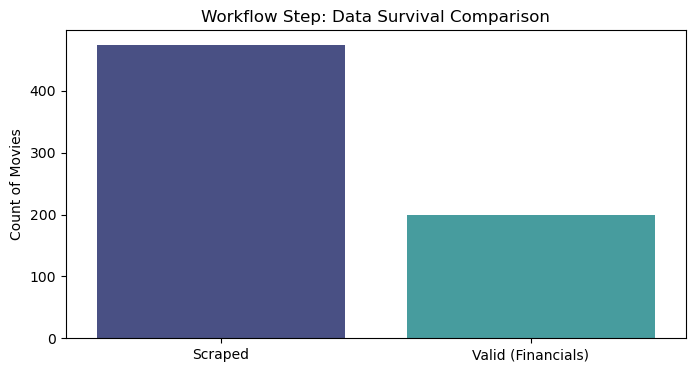

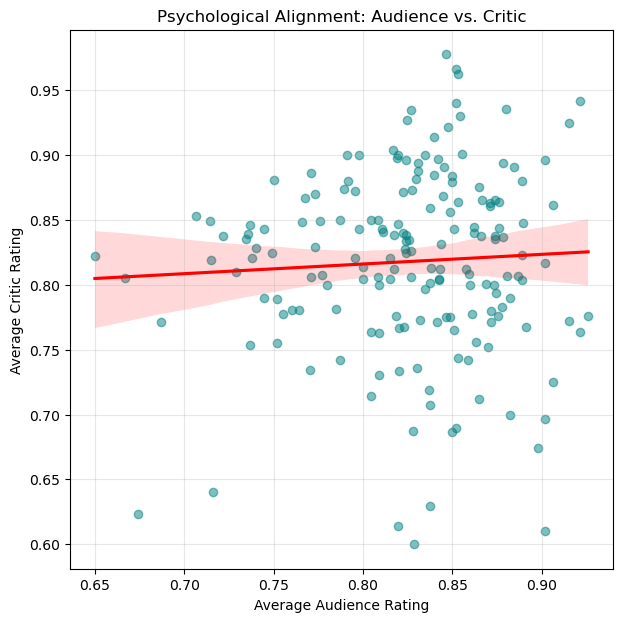

Sentiment Correlation Coefficient: 0.06
Checking Trial A (Individual): 12581 rows found with valid features.
--- Trial A (Individual) Results ---
Accuracy: 0.513 | F1-Score: 0.547 | AUC: 0.441

Checking Trial B (Collective): 191 rows found with valid features.
--- Trial B (Collective) Results ---
Accuracy: 0.534 | F1-Score: 0.561 | AUC: 0.455



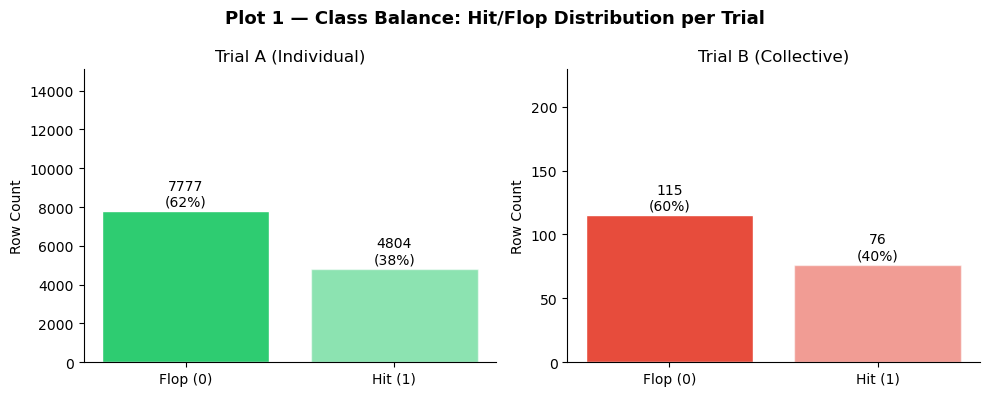

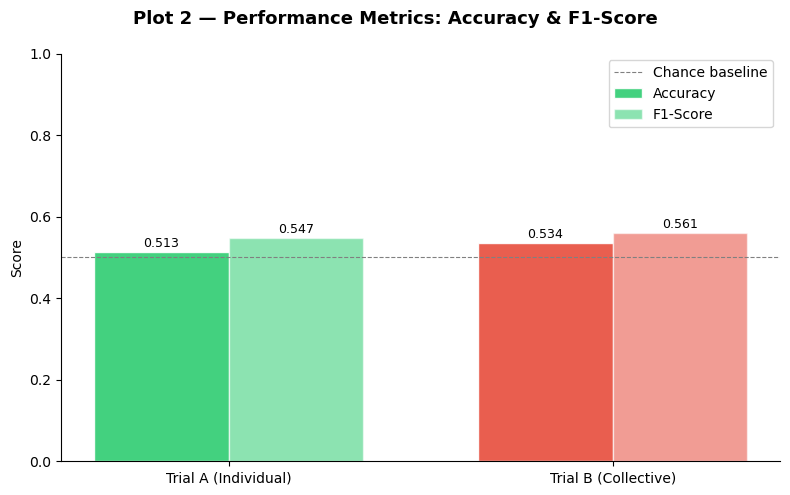

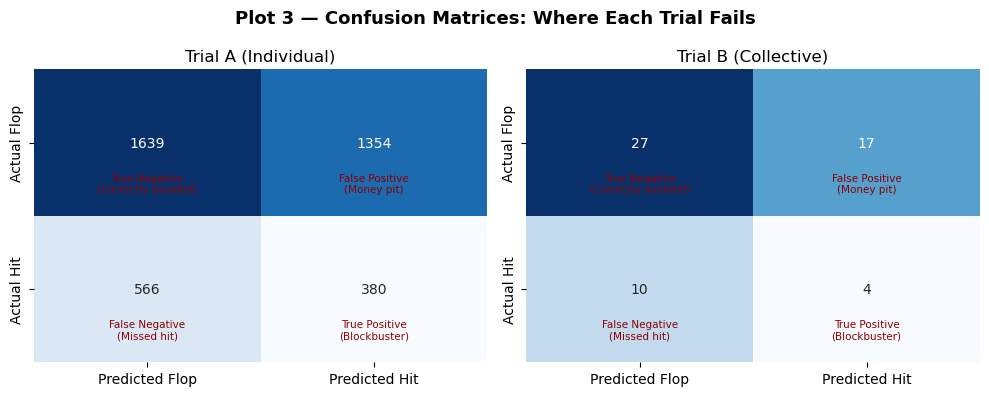

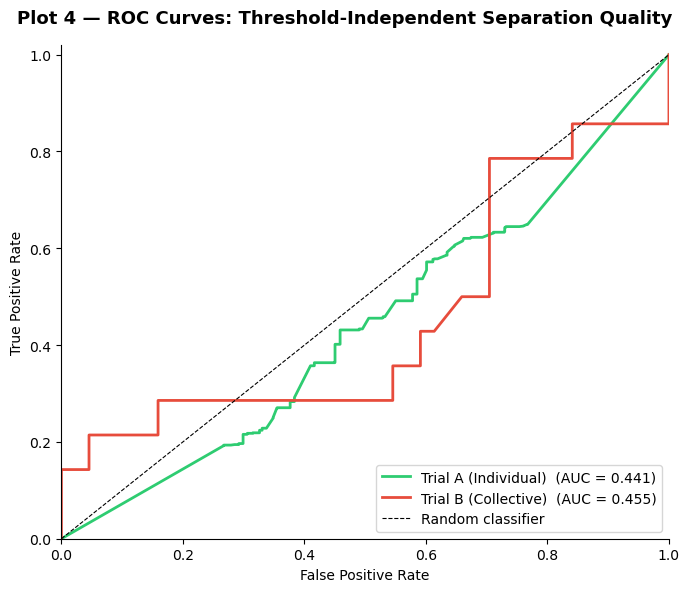

✅ The more accurate data structure is: Trial B (Collective)


In [9]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# execution 

# intialize and extract 
manager = MovieWorkflowManager()
full_dataset = manager.run_full_extraction()

# run eda 
manager.run_eda_visuals(full_dataset)

# generate trials
trial_a, trial_b = manager.generate_trials(full_dataset)
winning_trial_name = manager.compare_trials_initially(trial_a, trial_b)

In [ ]:
# Select Trial B for training volume
df_final = trial_b

gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(df_final, groups=df_final['movie_title']))
train_df, test_df = df_final.iloc[train_idx].copy(), df_final.iloc[test_idx].copy()

numeric_feats = ['user_rating', 'budget']

NameError: name 'trial_b' is not defined

In [ ]:
# ECONOMIC CONFUSION MATRIX
def plot_economic_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    # Manual check for binary cases
    if cm.shape == (1,1): # Handles edge cases where only one label is predicted
        print("Warning: Only one class predicted, Confusion Matrix plot skipped.")
        return
        
    labels = [
        ["True Negative", "False Positive)"],
        ["False Negative)", "True Positive"]
    ]
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=["Predicted Flop", "Predicted Hit"],
                yticklabels=["Actual Flop", "Actual Hit"])
    
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j+0.5, i+0.7, labels[i][j], ha='center', va='center', fontsize=10, color='darkred')
            
    plt.title(title)
    plt.show()

--- RUNNING METHOD 1: NUMERIC BASELINE ---
Method 1 (Numeric Only) F1-Score: 0.552



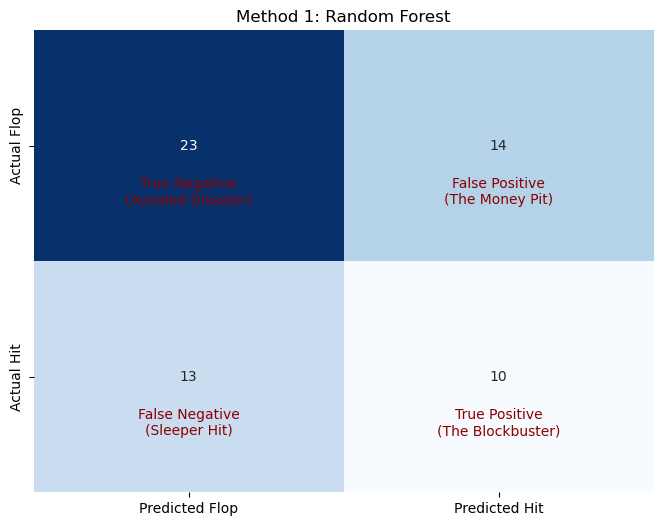

In [ ]:
# METHOD 1: RANDOM FOREST (Numeric Baseline Only)
print("--- RUNNING METHOD 1: NUMERIC BASELINE ---")

scaler = StandardScaler()
X_train_num = scaler.fit_transform(train_df[numeric_feats].fillna(0))
X_test_num = scaler.transform(test_df[numeric_feats].fillna(0))

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_num, train_df['label'])

m1_preds = rf_model.predict(X_test_num)
m1_f1 = f1_score(test_df['label'], m1_preds, average='weighted')

print(f"Method 1 (Numeric Only) F1-Score: {m1_f1:.3f}\n")
plot_economic_matrix(test_df['label'], m1_preds, "Method 1: Random Forest")

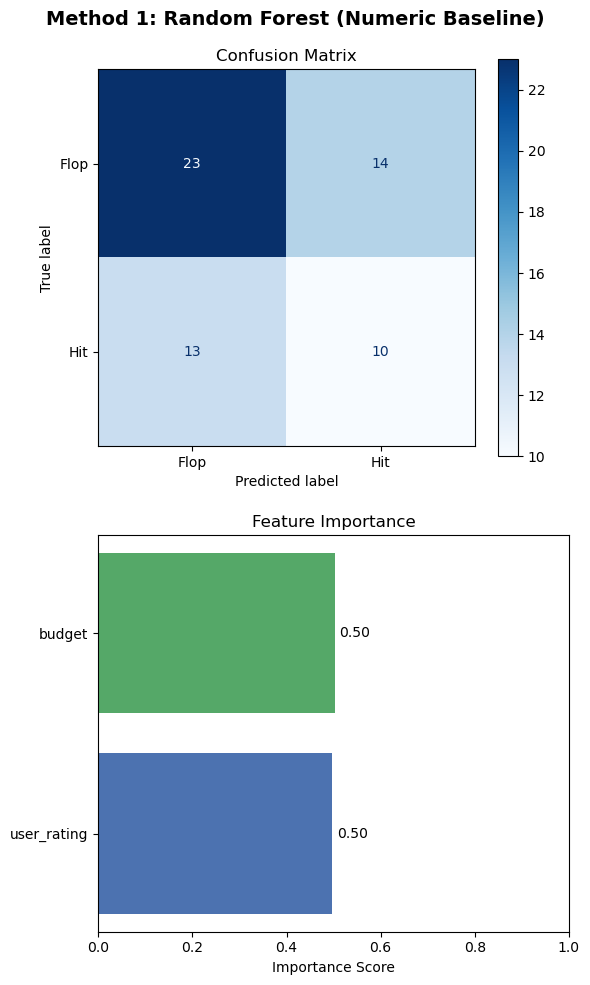

In [ ]:
# Visualisation: Confusion Matrix and Feature Importance for Method 1
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 1, figsize=(6, 10)) 
fig.suptitle("Method 1: Random Forest (Numeric Baseline)", fontsize=14, fontweight='bold')

# ── Left: Confusion Matrix ────────────────────────────────────────────────
ConfusionMatrixDisplay.from_predictions(
    test_df['label'], m1_preds,
    display_labels=["Flop", "Hit"],
    cmap="Blues",
    ax=axes[0]
)
axes[0].set_title("Confusion Matrix")

# ── Right: Feature Importance ─────────────────────────────────────────────
importances = rf_model.feature_importances_
axes[1].barh(numeric_feats, importances, color=["#4C72B0", "#55A868", "#C44E52"])
axes[1].set_xlabel("Importance Score")
axes[1].set_title("Feature Importance")
axes[1].set_xlim(0, 1)

for i, v in enumerate(importances):
    axes[1].text(v + 0.01, i, f"{v:.2f}", va='center', fontsize=10)

plt.tight_layout()
plt.show()


Using device for BERT: mps
--- RUNNING METHOD 2: BERT QUALITATIVE BASELINE ---


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


--- STARTING TRAINING ---


Epoch 1: 100%|██████████| 18/18 [00:17<00:00,  1.00it/s]


Epoch 1 average loss: 0.7152


Epoch 2: 100%|██████████| 18/18 [00:18<00:00,  1.02s/it]


Epoch 2 average loss: 0.6841
--- EVALUATING ---


Testing: 100%|██████████| 8/8 [00:05<00:00,  1.43it/s]


Method 2 (BERT Only) F1-Score: 0.470


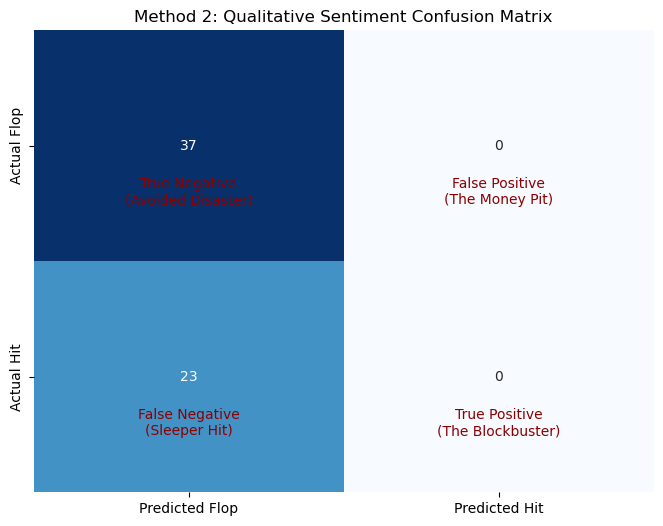

In [ ]:
# METHOD 2: BERT ONLY (Qualitative Baseline Only)

# 1. Set the device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available(): # For Apple Silicon Macs
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device for BERT: {device}")

class SimpleTextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        encoding = self.tokenizer(self.texts[i], truncation=True, padding='max_length', max_length=256, return_tensors='pt')
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[i], dtype=torch.long)
        }
    
print("--- RUNNING METHOD 2: BERT QUALITATIVE BASELINE ---")
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
m2_model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to(device)

# freeze all layers except top 2 
for name, param in m2_model.bert.named_parameters():
    if "encoder.layer.11" not in name and "encoder.layer.10" not in name:
        param.requires_grad = False

# Prepare DataLoaders
train_ds = SimpleTextDataset(train_df['review_text'].tolist(), train_df['label'].tolist(), tokenizer)
test_ds = SimpleTextDataset(test_df['review_text'].tolist(), test_df['label'].tolist(), tokenizer)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=8)

# Optimizer only passing parameters that require gradients
optimizer = AdamW(filter(lambda p: p.requires_grad, m2_model.parameters()), lr=2e-5)

# Training Loop
print("--- STARTING TRAINING ---")
m2_model.train()
for epoch in range(2): 
    total_loss = 0
    # Added tqdm for a progress bar so you know it's not frozen
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        optimizer.zero_grad()
        
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = m2_model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1} average loss: {total_loss/len(train_loader):.4f}")

print("--- EVALUATING ---")
m2_model.eval()
m2_preds = []
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        
        outputs = m2_model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        m2_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())

m2_f1 = f1_score(test_df['label'], m2_preds, average='weighted')
print(f"\nMethod 2 (BERT Only) F1-Score: {m2_f1:.3f}")


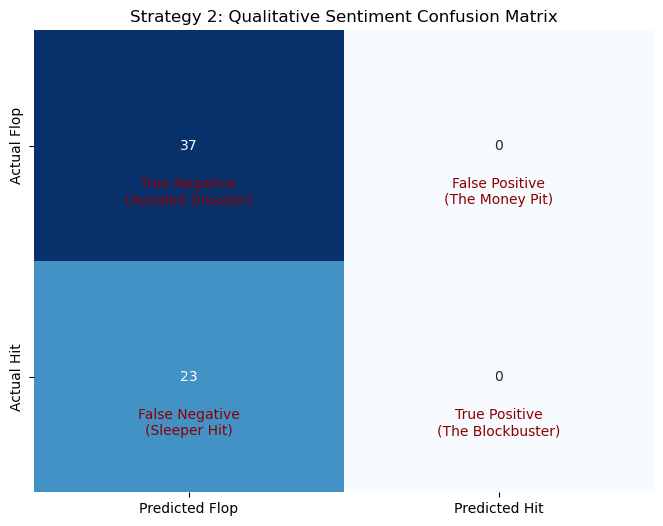

In [ ]:
plot_economic_matrix(test_df['label'], m2_preds, "Strategy 2: Qualitative Sentiment Confusion Matrix")

In [ ]:
# METHOD 3: TRAINING THE HYBRID

# hyperparameter tuning 
print("Running Hyperparameter tuning:")

def objective(trial, train_df, test_df, numeric_feats):
    lr = trial.suggest_float("lr", 0.0001, 0.001, log=True)
    hidden_dim = trial.suggest_categorical("hidden_dim", [128, 256, 512])
    dropout_prob = trial.suggest_float("dropout", 0.1, 0.4)
    batch_size = trial.suggest_categorical("batch_size", [8, 16])

    scaler = StandardScaler()
    X_tr_num = scaler.fit_transform(train_df[numeric_feats].fillna(0))
    X_te_num = scaler.transform(test_df[numeric_feats].fillna(0))
    
    tok = BertTokenizer.from_pretrained("bert-base-uncased")
    train_ldr = DataLoader(MovieDataset(train_df['review_text'].tolist(), X_tr_num, train_df['label'].tolist(), tok), 
                           batch_size=batch_size, shuffle=True)
    test_ldr = DataLoader(MovieDataset(test_df['review_text'].tolist(), X_te_num, test_df['label'].tolist(), tok), 
                          batch_size=batch_size)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # NOTE: Changed this to 'MovieClassifier' to match your class name
    model = MovieClassifier(len(numeric_feats), hidden_dim, dropout_prob).to(device)
    
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    model.train()
    for epoch in range(2): 
        for b in train_ldr:
            optimizer.zero_grad()
            out = model(b["ids"].to(device), b["mask"].to(device), b["num"].to(device))
            loss = criterion(out, b["lab"].to(device))
            loss.backward()
            optimizer.step()

    model.eval()
    preds, actuals = [], []
    with torch.no_grad():
        for b in test_ldr:
            logits = model(b["ids"].to(device), b["mask"].to(device), b["num"].to(device))
            p = (torch.sigmoid(logits) >= 0.5).int().cpu().numpy()
            preds.extend(p)
            actuals.extend(b["lab"].numpy())

    return f1_score(actuals, preds, average='weighted')

def run_hyperparameter_tuning(train_df, test_df, numeric_feats, n_trials=10):
    study = optuna.create_study(direction="maximize")
    study.optimize(lambda trial: objective(trial, train_df, test_df, numeric_feats), n_trials=n_trials)
    return study.best_params

print("RUNNING METHOD 3: HYBRID")

numeric_feats = ['user_rating', 'budget']
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tok = BertTokenizer.from_pretrained("bert-base-uncased")

best_params = run_hyperparameter_tuning(train_df, test_df, numeric_feats, n_trials=5)
# Extract the best settings found by Optuna
best_lr = best_params['lr']
best_batch = best_params['batch_size']
best_hidden_dim = best_params['hidden_dim']

# Scaling numeric data
X_tr_num = scaler.fit_transform(train_df[numeric_feats].fillna(0))
X_te_num = scaler.transform(test_df[numeric_feats].fillna(0))

# Preparing DataLoaders using your MovieDataset
train_ldr = DataLoader(
    MovieDataset(train_df['review_text'].tolist(), X_tr_num, train_df['label'].tolist(), tok), 
    batch_size=best_batch, 
    shuffle=True
)
test_ldr = DataLoader(
    MovieDataset(test_df['review_text'].tolist(), X_te_num, test_df['label'].tolist(), tok), 
    batch_size=best_batch
)

# Initializing your MovieClassifier
model_hybrid = MovieClassifier(
    n_dim=len(numeric_feats), 
    hidden_dim=best_params['hidden_dim'], 
    dropout_prob=best_params['dropout']
).to(device)
opt = AdamW(filter(lambda p: p.requires_grad, model_hybrid.parameters()), lr=best_lr)
crit = nn.BCEWithLogitsLoss()

# Training loop
model_hybrid.train()
for ep in range(3):
    total_loss = 0
    for b in train_ldr:
        opt.zero_grad()
        out = model_hybrid(b["ids"].to(device), b["mask"].to(device), b["num"].to(device))
        loss = crit(out, b["lab"].to(device))
        loss.backward()
        opt.step()
        total_loss += loss.item()
    print(f"Epoch {ep+1} | Loss: {total_loss/len(train_ldr):.4f}")

# Evaluation
model_hybrid.eval()
m3_probs = []
with torch.no_grad():
    for b in test_ldr:
        logits = model_hybrid(b["ids"].to(device), b["mask"].to(device), b["num"].to(device))
        m3_probs.extend(torch.sigmoid(logits).cpu().numpy())

m3_preds = (np.array(m3_probs) >= 0.5).astype(int)
m3_f1 = f1_score(test_df['label'], m3_preds, average='weighted')
print(f"Method 3 (Hybrid) F1-Score with Optimized Params: {m3_f1:.3f}")

Running Hyperparameter tuning:
RUNNING METHOD 3: HYBRID


NameError: name 'train_df' is not defined

In [ ]:
pip install torchview

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [torchview]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from torchview import draw_graph
import torch

# Assuming Strategy3HybridModel is your class name
model = model_hybrid(num_numeric_inputs=3)

# Generate the diagram
model_graph = draw_graph(model, input_data=[
    torch.randint(0, 100, (1, 128)), # input_ids
    torch.ones((1, 128)),            # mask
    torch.randn((1, 3))              # numeric_features
], expand_nested=True)

model_graph.visual_graph.render("hybrid_model_arch", format="png")

NameError: name 'model_hybrid' is not defined

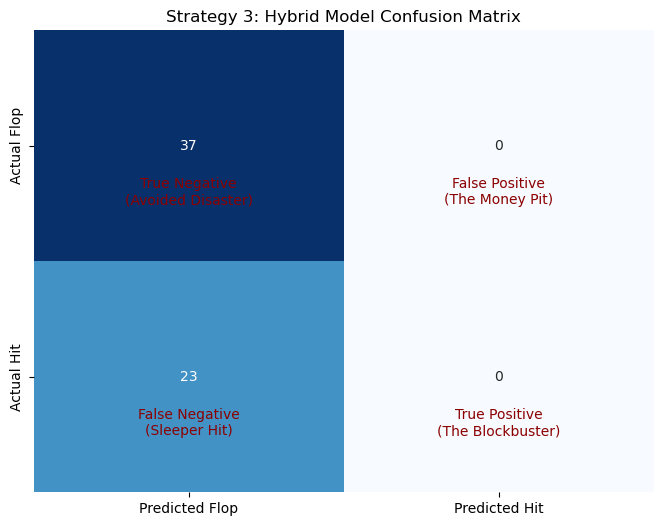

In [ ]:
plot_economic_matrix(test_df['label'], m3_preds, "Strategy 3: Hybrid Model Confusion Matrix")

--- RUNNING METHOD 4: BIDIRECTIONAL LSTM ---
Finding optimal hyperparameters...
Testing: LR=0.001, Hidden=64, Dropout=0.2
Result F1: 0.5401
Testing: LR=0.001, Hidden=64, Dropout=0.2
Result F1: 0.4791
Testing: LR=0.001, Hidden=64, Dropout=0.2
Result F1: 0.5562
Testing: LR=0.001, Hidden=64, Dropout=0.5
Result F1: 0.4896
Testing: LR=0.001, Hidden=64, Dropout=0.5
Result F1: 0.4625
Testing: LR=0.001, Hidden=64, Dropout=0.5
Result F1: 0.5448
Testing: LR=0.001, Hidden=128, Dropout=0.2
Result F1: 0.5209
Testing: LR=0.001, Hidden=128, Dropout=0.2
Result F1: 0.5431
Testing: LR=0.001, Hidden=128, Dropout=0.2
Result F1: 0.5231
Testing: LR=0.001, Hidden=128, Dropout=0.5
Result F1: 0.5448
Testing: LR=0.001, Hidden=128, Dropout=0.5
Result F1: 0.5145
Testing: LR=0.001, Hidden=128, Dropout=0.5
Result F1: 0.5368
Testing: LR=0.001, Hidden=256, Dropout=0.2
Result F1: 0.5313
Testing: LR=0.001, Hidden=256, Dropout=0.2
Result F1: 0.5683
Testing: LR=0.001, Hidden=256, Dropout=0.2
Result F1: 0.5291
Testing: LR

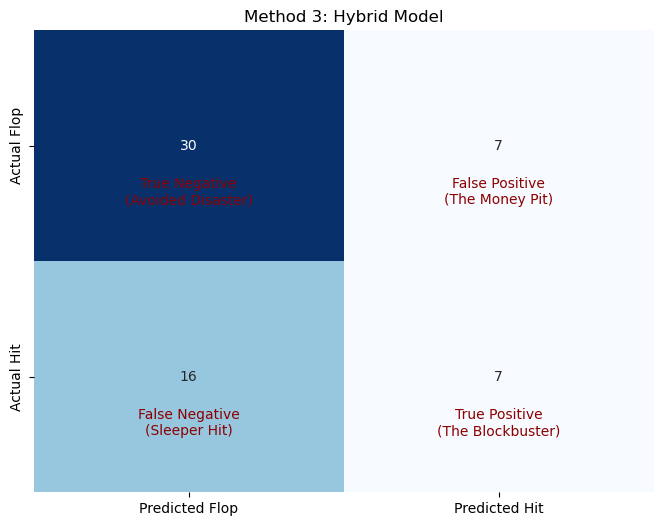

In [ ]:
# method 4: LSTM 

# 1. SIMPLE VOCABULARY BUILDER

# To use an LSTM, we must turn words into integers manually.
def build_vocab(texts, max_vocab=10000):
    words = " ".join(texts).lower().split()
    count = Counter(words)
    # Filter for most common words
    vocab = {word: i+2 for i, (word, _) in enumerate(count.most_common(max_vocab))}
    vocab["<PAD>"] = 0
    vocab["<UNK>"] = 1
    return vocab

def text_to_indices(text, vocab):
    return [vocab.get(word.lower(), 1) for word in str(text).split()]

# hyperparameter tuner
def tune_lstm(train_indices, train_labels, test_indices, test_labels, vocab, device):
    lrs = [0.001, 0.0005, 0.0001]
    hiddens = [64, 128, 256]
    dropouts = [0.2, 0.5]
    embed_dims = [100, 200, 300]
    
    best_f1 = 0
    best_params = {}

    # Pre-pad data
    X_train = pad_sequence(train_indices, batch_first=True, padding_value=0)[:, :512].to(device)
    y_train = torch.tensor(train_labels.values, dtype=torch.float32).to(device)
    X_test = pad_sequence(test_indices, batch_first=True, padding_value=0)[:, :512].to(device)
    
    for lr in lrs:
        for hd in hiddens:
            for dr in dropouts:
                for ed in embed_dims:
                    print(f"Testing: LR={lr}, Hidden={hd}, Dropout={dr}")
                    model = MovieLSTM(len(vocab), ed, hd, dr).to(device) 
                    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
                    criterion = nn.BCEWithLogitsLoss()
                    
                    model.train()
                    for epoch in range(5):
                        optimizer.zero_grad()
                        out = model(X_train)
                        loss = criterion(out, y_train)
                        loss.backward()
                        optimizer.step()
                    
                    model.eval()
                    with torch.no_grad():
                        logits = model(X_test)
                        preds = (torch.sigmoid(logits) >= 0.5).int().cpu().numpy()
                        score = f1_score(test_labels, preds, average='weighted')
                    
                    print(f"Result F1: {score:.4f}")
                    if score > best_f1:
                        best_f1 = score
                        best_params = {'lr': lr, 'hidden': hd, 'dropout': dr, 'embed': ed} 
    
    return best_params

# 2. LSTM ARCHITECTURE (Sequential Memory Model)
class MovieLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout_prob=0.3):
        super(MovieLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        # Bidirectional=True mimics reading the review forward and backward
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        # 2 * hidden_dim because it is bidirectional
        self.dropout = nn.Dropout(dropout_prob) 
        self.fc = nn.Linear(hidden_dim * 2, 1)
        
    def forward(self, x):
        embedded = self.embedding(x)
        # We only take the final hidden state (the "memory") to make the prediction
        _, (hidden, _) = self.lstm(embedded)
        # Concatenate the final forward and backward hidden states
        hidden_cat = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        hidden_cat = self.dropout(hidden_cat) 
        return self.fc(hidden_cat).squeeze(1)

# 3. PREPARATION & TRAINING
print("--- RUNNING METHOD 4: BIDIRECTIONAL LSTM ---")

# Use df_final (your winning trial)
vocab = build_vocab(train_df['review_text'])
train_indices = [torch.tensor(text_to_indices(t, vocab)) for t in train_df['review_text']]
test_indices = [torch.tensor(text_to_indices(t, vocab)) for t in test_df['review_text']]

# run tuner 
print("Finding optimal hyperparameters...")
best_configs = tune_lstm(train_indices, train_df['label'], test_indices, test_df['label'], vocab, device)

# data prep
X_train_lstm = pad_sequence(train_indices, batch_first=True, padding_value=0)[:, :512]
X_test_lstm = pad_sequence(test_indices, batch_first=True, padding_value=0)[:, :512]
y_train_lstm = torch.tensor(train_df['label'].values, dtype=torch.float32)

# final training 
print(f"Training final LSTM with: {best_configs}")
lstm_model = MovieLSTM(len(vocab), 128, best_configs['hidden'], best_configs['dropout']).to(device)
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=best_configs['lr'])
criterion = nn.BCEWithLogitsLoss()

# Training Loop
lstm_model.train()
for epoch in range(5): 
    optimizer.zero_grad()
    outputs = lstm_model(X_train_lstm.to(device))
    loss = criterion(outputs, y_train_lstm.to(device))
    loss.backward()
    torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=1.0)
    optimizer.step()
    print(f"Epoch {epoch+1} Loss: {loss.item():.4f}")

# 4. EVALUATION
lstm_model.eval()
with torch.no_grad():
    m4_logits = lstm_model(X_test_lstm.to(device))
    m4_preds = (torch.sigmoid(m4_logits) >= 0.5).int().cpu().numpy()

m4_f1 = f1_score(test_df['label'], m4_preds, average='weighted')
print(f"\nMethod 4 (LSTM) F1-Score: {m4_f1:.3f}")

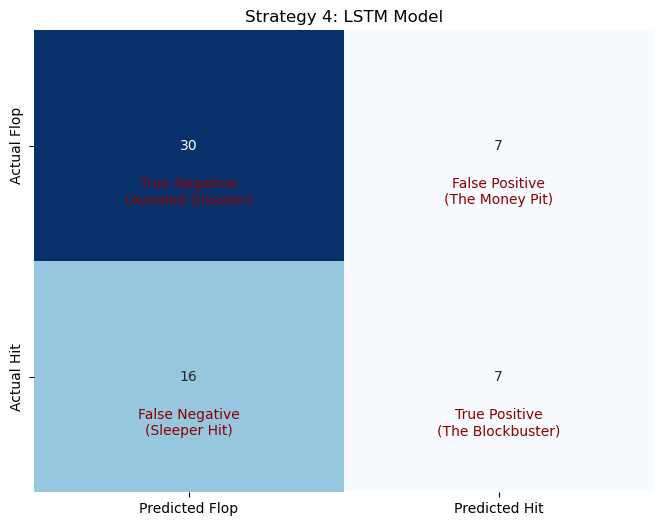

In [ ]:
plot_economic_matrix(test_df['label'], m4_preds, "Strategy 4: LSTM Model")

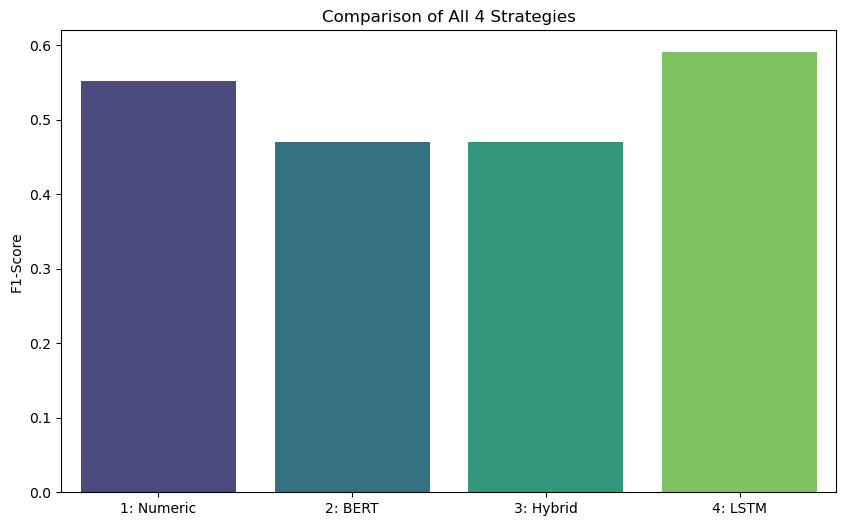

In [ ]:
# Final Comparison Chart 
plt.figure(figsize=(10, 6))
methods = ['1: Numeric', '2: BERT', '3: Hybrid', '4: LSTM']
scores = [m1_f1, m2_f1, m3_f1, m4_f1]
sns.barplot(x=methods, y=scores, palette="viridis")
plt.title("Comparison of All 4 Strategies")
plt.ylabel("F1-Score")
plt.show()

Audience F1: 0.662
Critics F1: 0.531


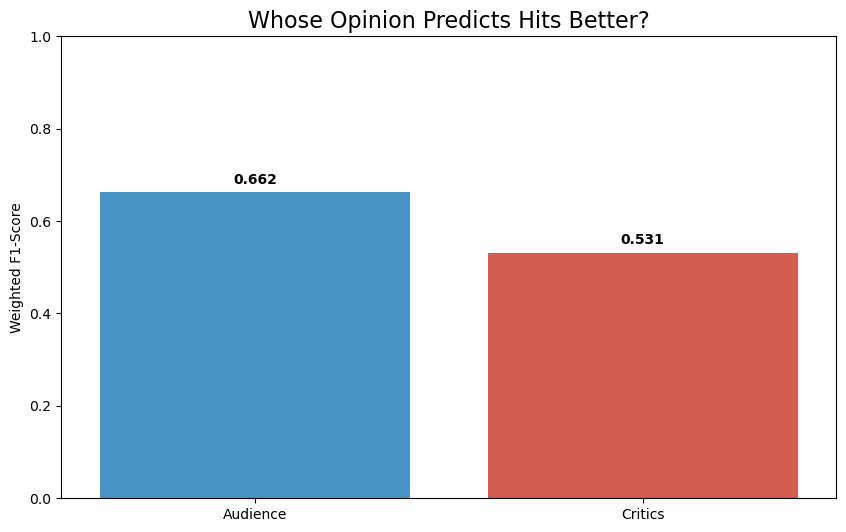

In [ ]:
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence
from sklearn.metrics import f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════════════════════
# 1. THE HYBRID LSTM ARCHITECTURE (The "Strategy 4" Style)
# ══════════════════════════════════════════════════════════════════════════════
class HybridLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_numeric_feats):
        super(HybridLSTM, self).__init__()
        # Text Branch (The LSTM "Memory")
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        
        # Numeric Branch (The "Fact" MLP)
        self.num_branch = nn.Sequential(
            nn.Linear(num_numeric_feats, 64),
            nn.ReLU()
        )
        
        # Fusion Layer (Concatenates LSTM 128-dim + MLP 64-dim)
        self.fusion = nn.Sequential(
            nn.Linear((hidden_dim * 2) + 64, 256),
            nn.ReLU(),
            nn.Linear(256, 1)
        )
        
    def forward(self, text, numeric):
        # Process Text
        embedded = self.embedding(text)
        _, (hidden, _) = self.lstm(embedded)
        text_f = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        
        # Process Numbers
        num_f = self.num_branch(numeric)
        
        # Concatenate & Predict
        combined = torch.cat((text_f, num_f), dim=1)
        return self.fusion(combined).squeeze(1)

# ══════════════════════════════════════════════════════════════════════════════
# 2. RUN THE RESEARCH SHOWDOWN
# ══════════════════════════════════════════════════════════════════════════════
def run_hybrid_showdown_plot(df):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    numeric_cols = ['user_rating', 'year', 'budget']
    
    # --- FIX THE TYPEERROR: Force all reviews to strings ---
    df['review_text'] = df['review_text'].fillna("").astype(str)
    vocab = build_vocab(df['review_text'].tolist())
    
    cohorts = {
        "Audience": df[df['is_critic'] == 0],
        "Critics":  df[df['is_critic'] == 1]
    }
    
    final_scores = {}

    for name, sub_df in cohorts.items():
        # Clean specific sub-group
        clean_sub = sub_df.dropna(subset=numeric_cols + ['label']).copy()
        
        # Prepare Inputs
        indices = [torch.tensor(text_to_indices(t, vocab)) for t in clean_sub['review_text']]
        scaler = StandardScaler()
        numeric_vals = scaler.fit_transform(clean_sub[numeric_cols])
        
        # Split
        gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
        train_idx, test_idx = next(gss.split(indices, clean_sub['label'], groups=clean_sub['movie_title']))
        
        # Tensors
        X_tr_txt = pad_sequence([indices[i] for i in train_idx], batch_first=True, padding_value=0)[:, :256].to(device)
        X_te_txt = pad_sequence([indices[i] for i in test_idx], batch_first=True, padding_value=0)[:, :256].to(device)
        X_tr_num = torch.tensor(numeric_vals[train_idx], dtype=torch.float32).to(device)
        X_te_num = torch.tensor(numeric_vals[test_idx], dtype=torch.float32).to(device)
        y_tr = torch.tensor(clean_sub['label'].iloc[train_idx].values, dtype=torch.float32).to(device)
        y_te = clean_sub['label'].iloc[test_idx].values
        
        # Initialize Hybrid LSTM
        model = HybridLSTM(len(vocab), 128, 64, len(numeric_cols)).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
        criterion = nn.BCEWithLogitsLoss()
        
        # Training
        model.train()
        for epoch in range(5):
            optimizer.zero_grad()
            out = model(X_tr_txt, X_tr_num)
            loss = criterion(out, y_tr)
            loss.backward()
            optimizer.step()
            
        # Evaluation
        model.eval()
        with torch.no_grad():
            preds = (torch.sigmoid(model(X_te_txt, X_te_num)) >= 0.5).int().cpu().numpy()
            
        final_scores[name] = f1_score(y_te, preds, average='weighted')
        print(f"{name} F1: {final_scores[name]:.3f}")

    # ══════════════════════════════════════════════════════════════════════════
    # 3. FINAL PLOT FOR SLIDE 28
    # ══════════════════════════════════════════════════════════════════════════
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x=list(final_scores.keys()), y=list(final_scores.values()), palette=["#3498db", "#e74c3c"])
    
    #plt.axhline(y=df['label'].value_counts(normalize=True).max(), color='black', linestyle='--', label='Majority Class Baseline')
    plt.title("Whose Opinion Predicts Hits Better?", fontsize=16)
    plt.ylabel("Weighted F1-Score")
    plt.ylim(0, 1.0)
    
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.3f'), (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 9), textcoords='offset points', weight='bold')
    plt.show()

# EXECUTE THE FINAL STUDY
run_hybrid_showdown_plot(full_dataset)

In [ ]:
graph TD
    %% Inputs
    In1[Review Text] --> B[BERT Base Encoder]
    In2[Numeric Metadata] --> S[StandardScaler]

    %% Qualitative Branch
    B --> B2["[CLS] Token Extraction<br/>(768-dim Vector)"]

    %% Quantitative Branch
    S --> M1[Linear Layer]
    M1 --> M2[ReLU Activation]
    M2 --> M3[Dropout Layer]
    M3 --> M4["Feature Projection<br/>(64-dim Vector)"]

    %% The Fusion
    B2 --> F[CONCATENATION LAYER]
    M4 --> F

    %% The Head
    F --> H1["Fusion Vector<br/>(832-dim)"]
    H1 --> H2[Bottleneck Linear Layer]
    H2 --> H3[ReLU + Dropout]
    H3 --> H4[Final Output Linear Layer]

    %% Loss/Pred
    H4 --> L{BCEWithLogitsLoss}
    L --> P[ROI Success Prediction]

SyntaxError: invalid syntax (3876218334.py, line 1)